# Generation

In [1]:
import pickle

def read_pickle(file_path : str):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data

analysis = read_pickle('./data/analysis.pickle')
documents = read_pickle('./data/documents.pickle')

In [2]:
from src import Model, llm, QueryModel
from pydantic import Field

class IndicatorModel(Model):
    """
    Целевой показатель генерального плана
    """
    name : str = Field(description='Название показателя')
    unit : str = Field(description='Единица измерения')
    justification : str = Field(description='Обоснование и предпосылки разработки выбранного целевого показателя')

class IndicatorsModel(Model):
    """
    Перечень целевых показателей разрабатываемого генерального плана
    """
    indicators : list[IndicatorModel] = Field(min_length=1, description='Пречень целевых показателей')

In [3]:
class SmartIndicator(Model):
    """
    Оценка целевого показателя генерального плана согласно методике SMART
    """
    specific : str = Field(description='Показатель подразумевает один конкретный результат и не допускает разночтений')
    measurable : str = Field(description='Показатель имеет критерии оценки и является измеримым')
    achievable : str = Field(description='Показатель является достижимым: укладывается в сроки и опирается на объективные показатели')
    relevant : str = Field(description='Показатель является значимым и соответствует глобальной цели')
    time_bound : str = Field(description='Ограниченность во времени')
    
    result : str = Field(description='Итог')

class SmartModel(Model):
    """
    Оценка целевых показателей разрабатываемого генерального плана согласно методике SMART
    """
    smart_indicators : list[SmartIndicator] = Field(min_length=1, description='Перечень целевых показателей')
    approve_score : float = Field(ge=0, le=1, description='Итоговая оценка качества целевых показателей')

In [4]:
class CoherenceModel(Model):
    """
    Анализ согласованности целевых показателей разрабатываемого генерального плана с исходными данными территории и документами
    """
    missed_indicators : str = Field(description='Целевые показатели, имеющие слабую привязку к исходным данным или документам')
    missed_preliminaries : str = Field(description='Важные аспекты исходных данных и документов, упущенные из виду при разработке целевых показателей')
    approve_score : float = Field(ge=0, le=1, description='Итоговая оценка качества целевых показателей')

In [5]:
class State(Model):
    analysis : str
    documents : str
    indicators : IndicatorsModel | None = None
    smart : SmartModel | None = None
    coherence : CoherenceModel | None = None
    iteration : int = 0
    approve : bool = False

In [ ]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage, AIMessage, SystemMessage

def indicators_node(state : State):
    agent = create_agent(
        model=llm,
        tools=[],
        system_prompt='На основе полученных данных сформируй перечень целевых показателей генерального плана населенного пункта.',
        response_format=IndicatorsModel,
    )
    iteration = state.iteration + 1

    messages = [HumanMessage(str({'analysis':state.analysis,'documents':state.documents}))]
    if state.indicators is not None:
        messages.append(AIMessage(str(state.indicators.model_dump())))
    if (state.smart is not None) and (state.coherence is not None):
        messages.append(HumanMessage(str({
            'smart': str(state.smart),
            'coherence': str(state.coherence)
        })))
    response = agent.invoke({'messages':messages})
    return {
        'indicators': response['structured_response'],
        'iteration': iteration
    }

def smart_node(state : State):
    agent = create_agent(
        model=llm,
        tools=[],
        system_prompt='Оцени показатели по методике SMART в контексте генерального (пространственного) планирования.',
        response_format=SmartModel,
    )

    messages = []
    # if state.smart is not None:
    #     messages.append(AIMessage(str(state.coherence.model_dump())))
    messages.append(HumanMessage(str(state.indicators)))

    response = agent.invoke({'messages':messages})
    return {
        'smart': response['structured_response']
    }

def coherence_node(state : State):
    agent = create_agent(
        model=llm,
        tools=[],
        response_format=CoherenceModel,
    )

    messages = []
    # if state.coherence is not None:
    #     messages.append(AIMessage(str(state.coherence.model_dump())))
    messages.append(HumanMessage(str({
        'analysis': state.analysis,
        'documents': state.documents,
        'indicators': state.indicators
    })))

    response = agent.invoke({'messages':messages})
    return {
        'coherence': response['structured_response']
    }

def result_node(state : State):
    smart = state.smart.approve_score
    coherence = state.coherence.approve_score
    print(smart, coherence)
    score = (smart + coherence) / 2
    return {
        'approve': score >= 0.9
    }

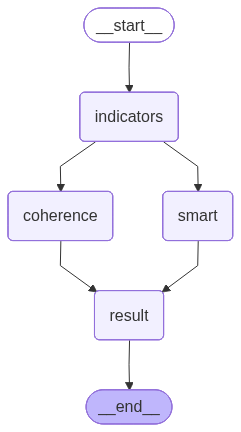

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

graph.add_node('indicators', indicators_node)
graph.add_node('smart', smart_node)
graph.add_node('coherence', coherence_node)
graph.add_node('result', result_node)

graph.add_edge(START, 'indicators')
graph.add_edge('indicators', 'smart')
graph.add_edge('indicators', 'coherence')
graph.add_edge('smart', 'result')
graph.add_edge('coherence', 'result')

graph.add_conditional_edges('result', lambda s : END if (s.approve or s.iteration >= 10) else 'indicators')

graph = graph.compile()
graph

In [8]:
res = graph.invoke({
    'analysis': analysis,
    'documents': documents
})

0.85 0.7


: 

: 

In [ ]:
import pickle

with open('./data/generation.pickle', 'wb') as file:
    pickle.dump(str(res), file)

In [69]:
res['indicators'].model_dump()

{'indicators': [{'name': 'Численность постоянного населения города Гатчина',
   'unit': 'тыс. человек',
   'justification': 'На основе текущей численности населения 94,4 тыс. человек (2018) и демографических тенденций (естественная убыль -5,3 чел. на 1000 жителей, сокращение миграционного прироста). Целевой показатель учитывает необходимость стабилизации демографической ситуации и создание условий для роста населения как основы социально-экономического развития города.'},
  {'name': 'Уровень жилищной обеспеченности населения',
   'unit': 'кв.м/чел.',
   'justification': 'Текущий показатель для Гатчины составляет 24,12 кв.м/чел. (2018), что ниже среднеобластного значения 26,36 кв.м/чел. Целевой показатель направлен на повышение качества жилищных условий населения, учитывая активное жилищное строительство и необходимость замены ветхого и аварийного жилищного фонда.'},
  {'name': 'Доля ветхого и аварийного жилищного фонда',
   'unit': '% от общего жилищного фонда',
   'justification': 'В 

In [70]:
res['indicators'].model_dump()

{'indicators': [{'name': 'Численность постоянного населения города Гатчина',
   'unit': 'тыс. человек',
   'justification': 'На основе текущей численности населения 94,4 тыс. человек (2018) и демографических тенденций (естественная убыль -5,3 чел. на 1000 жителей, сокращение миграционного прироста). Целевой показатель учитывает необходимость стабилизации демографической ситуации и создание условий для роста населения как основы социально-экономического развития города.'},
  {'name': 'Уровень жилищной обеспеченности населения',
   'unit': 'кв.м/чел.',
   'justification': 'Текущий показатель для Гатчины составляет 24,12 кв.м/чел. (2018), что ниже среднеобластного значения 26,36 кв.м/чел. Целевой показатель направлен на повышение качества жилищных условий населения, учитывая активное жилищное строительство и необходимость замены ветхого и аварийного жилищного фонда.'},
  {'name': 'Доля ветхого и аварийного жилищного фонда',
   'unit': '% от общего жилищного фонда',
   'justification': 'В 

In [80]:
res['indicators'].model_dump()['indicators']

[{'name': 'Численность постоянного населения города Гатчина',
  'unit': 'тыс. человек',
  'justification': 'На основе текущей численности населения 94,4 тыс. человек (2018) и демографических тенденций (естественная убыль -5,3 чел. на 1000 жителей, сокращение миграционного прироста). Целевой показатель учитывает необходимость стабилизации демографической ситуации и создание условий для роста населения как основы социально-экономического развития города.'},
 {'name': 'Уровень жилищной обеспеченности населения',
  'unit': 'кв.м/чел.',
  'justification': 'Текущий показатель для Гатчины составляет 24,12 кв.м/чел. (2018), что ниже среднеобластного значения 26,36 кв.м/чел. Целевой показатель направлен на повышение качества жилищных условий населения, учитывая активное жилищное строительство и необходимость замены ветхого и аварийного жилищного фонда.'},
 {'name': 'Доля ветхого и аварийного жилищного фонда',
  'unit': '% от общего жилищного фонда',
  'justification': 'В городе существует пробл

In [85]:
import pandas as pd

res['indicators'].model_dump()['indicators']

[{'name': 'Численность постоянного населения города Гатчина',
  'unit': 'тыс. человек',
  'justification': 'На основе текущей численности населения 94,4 тыс. человек (2018) и демографических тенденций (естественная убыль -5,3 чел. на 1000 жителей, сокращение миграционного прироста). Целевой показатель учитывает необходимость стабилизации демографической ситуации и создание условий для роста населения как основы социально-экономического развития города.'},
 {'name': 'Уровень жилищной обеспеченности населения',
  'unit': 'кв.м/чел.',
  'justification': 'Текущий показатель для Гатчины составляет 24,12 кв.м/чел. (2018), что ниже среднеобластного значения 26,36 кв.м/чел. Целевой показатель направлен на повышение качества жилищных условий населения, учитывая активное жилищное строительство и необходимость замены ветхого и аварийного жилищного фонда.'},
 {'name': 'Доля ветхого и аварийного жилищного фонда',
  'unit': '% от общего жилищного фонда',
  'justification': 'В городе существует пробл